# Linear Regression
**Linear regression** is a method used to model the relationship between the target and feature(s) by fitting the best straight line or surface through the data with the least error. This is best designed for regression problems, where we seek to predict some continuous value.

## Linear Regression without Scikit
This is the process of linear regression without using scikit-learn classes. Our goal is to infer the mass of a penguin using its flipper length

In [17]:
import pandas as pd

penguins = pd.read_csv("../penguins.csv")
penguins.dropna(inplace=True)
penguins

,rowid,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,6,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007
...,...,...,...,...,...,...,...,...,...
339,340,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
340,341,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
341,342,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
342,343,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009


Text(0.5, 1.0, 'Body Mass as a function of Flipper Length')

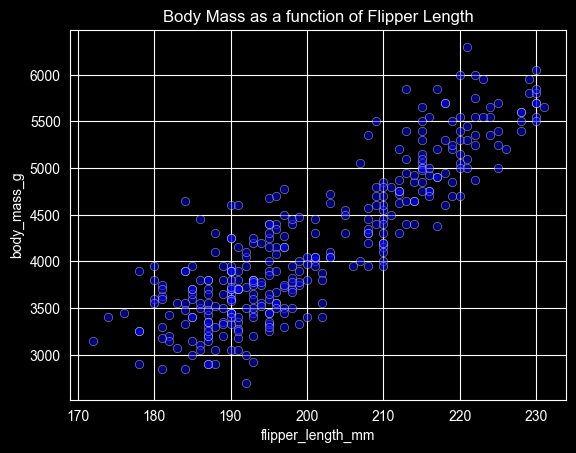

In [18]:
import seaborn as sns

feature_name = "flipper_length_mm"
target_name = "body_mass_g"
data, target = penguins[[feature_name]], penguins[target_name]

ax = sns.scatterplot(
    data=penguins,
    x=feature_name,
    y=target_name,
    color="blue",
    alpha=0.5,
)
ax.set_title("Body Mass as a function of Flipper Length")

In [9]:
def linear_model_flipper_mass(
    flipper_length, # x
    weight_flipper_length, # m
    intercept_body_mass # y
):
    body_mass = weight_flipper_length * flipper_length + intercept_body_mass
    return body_mass

We have defined our linear model in the form of `y = mx + b`. Now, we can generate a random weight for our single input feature and the intercept.

In [10]:
import numpy as np

weight_flipper_length = 45
intercept_body_mass = -5000

flipper_length_range = np.linspace(data.min(), data.max(), num=300)
predicted_body_mass = linear_model_flipper_mass(
    flipper_length_range,
    weight_flipper_length,
    intercept_body_mass
)

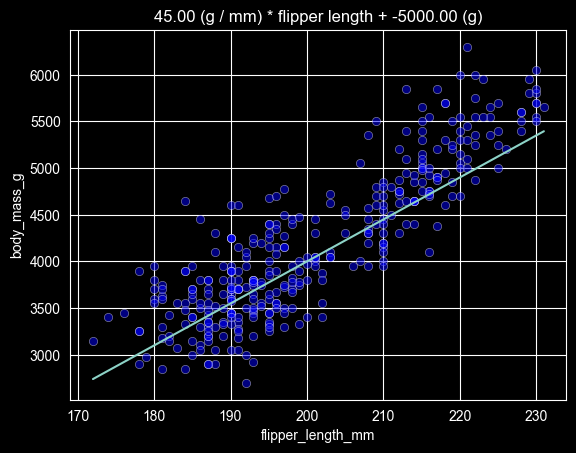

In [12]:
label = "{0:.2f} (g / mm) * flipper length + {1:.2f} (g)"

ax = sns.scatterplot(
    data=penguins, x=feature_name, y=target_name, color="blue", alpha=0.5
)
ax.plot(flipper_length_range, predicted_body_mass)
_ = ax.set_title(label.format(weight_flipper_length, intercept_body_mass))

## Linear Regression with Scikit

In [19]:
from sklearn.linear_model import LinearRegression

linear_regression = LinearRegression()
linear_regression.fit(data, target)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
weight_flipper_length = linear_regression.coef_[0]
weight_flipper_length

np.float64(50.15326594224113)

In [21]:
intercept_body_mass = linear_regression.intercept_
intercept_body_mass

np.float64(-5872.092682842825)

In [22]:
import numpy as np

flipper_length_range = np.linspace(data.min(), data.max(), num=300)
predicted_body_mass = (
    weight_flipper_length * flipper_length_range + intercept_body_mass
)

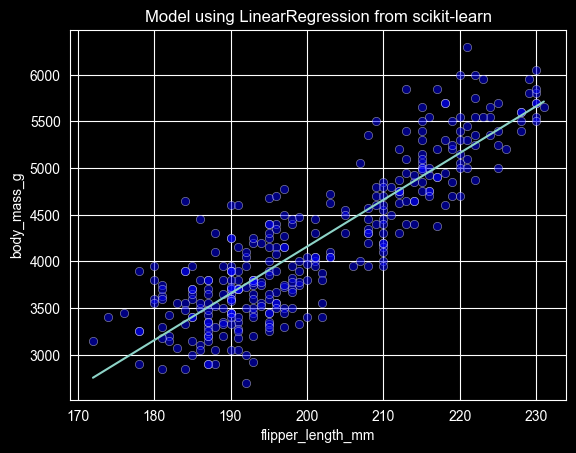

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(x=data[feature_name], y=target, color="blue", alpha=0.5)
plt.plot(flipper_length_range, predicted_body_mass)
_ = plt.title("Model using LinearRegression from scikit-learn")

We are able to determine how well the model fits using different metrics:
- **Mean squared error**: the mean of all squared value of actual minus predicted. This can be difficult to interpret.
- **Mean absolute error**: the mean of all absolute value of actual minus predicted. This can be easier to interpret as it is in the same unit as the target.

In [26]:
from sklearn.metrics import mean_squared_error

inferred_body_mass = linear_regression.predict(data)
model_error = mean_squared_error(
    target,
    inferred_body_mass
)
model_error

153789.67786691786

In [27]:
from sklearn.metrics import mean_absolute_error

model_error = mean_absolute_error(
    target,
    inferred_body_mass
)
model_error

312.08474571800963